This Notebook is mostly used for testing and is therefore filled with a lot of experimental code and non-working code. The actual substance has been transfered to the `evalutation.ipynb` notebook.

In [37]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings

In [38]:
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")

mask (generic function with 2 methods)

In [39]:
# include("test.jl")

In [40]:
import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    # @show 1
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    # @show 2
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

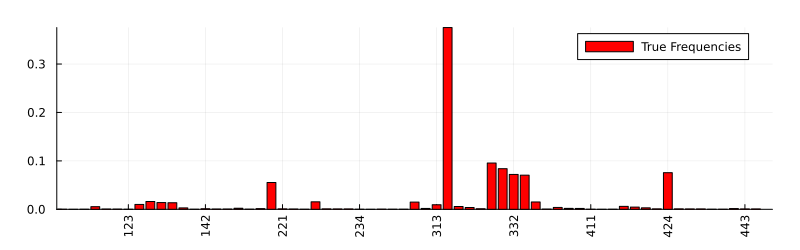

In [41]:
#Setting up a toy Markov sequence generator
S = [0.06591801058555521, 0.07969206822877058, 0.7577065839917972, 0.09668333719387696]
M1 = [0.08846562872099392 0.16990851783433247 0.7057593661240716 0.035866487320601916; 0.7431475939699389 0.21587009667771628 0.03183492266912633 0.009147386683218569; 0.5299436666548881 0.14037279287634963 0.31880667650890665 0.010876863959855763; 0.06768187476034546 0.8712803961334261 0.026959057317955764 0.03407867178827272]
M2 = [0.03711853694508748 0.004654670142378095 0.02356516471832978 0.9346616281942046; 0.05468190341435613 0.035849693778767566 0.010983526474084716 0.8984848763327916; 0.34718976966999127 0.29844003126407787 0.29174999882526814 0.06262020024066273; 0.06343354243884528 0.46980429610053 0.23584821143715762 0.23091395002346707]


#=
#If you wanted to draw the seq gen randomly
S = exp.(randn(4) .* 1.5)
S ./= sum(S)

M1 = exp.(randn(4,4) .* 1.5)
M1 ./= sum(M1 , dims = 2)

M2 = exp.(randn(4,4) .* 1.5)
M2 ./= sum(M2 , dims = 2)
=#


function target_sample(;S = S, M1 = M1, M2 = M2)
    a = rand(Categorical(S))
    b = rand(Categorical(M1[a,:]))
    c = rand(Categorical(M2[b,:]))
    return [a,b,c]
end

seq_matrix = hcat([[k,j,i] for i in 1:4, j in 1:4, k in 1:4]...)
all_seqs = [seq_matrix[:,i] for i in 1:size(seq_matrix,2)];
prob_seq(seq,S,M1,M2) = S[seq[1]]*M1[seq[1],seq[2]]*M2[seq[2],seq[3]]
all_probs = prob_seq.(all_seqs,Ref(S),Ref(M1),Ref(M2));

bar([join(string.(a)) for a in all_seqs], all_probs,
    xrotation = 90, size = (800,250), label = "True Frequencies",
    color = "red", margins = 0.5Plots.cm, xlim = (0,65))

In [42]:
#Setting up the model
alph = 5 #number of characters
hidden_size = 64

#We encode T with a non-trainable random projection
rff = RandomFourierFeatures(hidden_size, 1.0f0)

#A simple model that takes the full noised sequence and T,
#and returns the logits for each variable in the sequence
embed = Chain(Dense(15,hidden_size,leakyrelu),Dense(hidden_size,hidden_size,leakyrelu))
decode = Chain(
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size),LayerNorm(hidden_size),leakyrelu,
    Dense(hidden_size, hidden_size÷2),LayerNorm(hidden_size÷2),leakyrelu,
    Dense(hidden_size÷2, 15)
)
model(x,T) = reshape(
    decode(
        embed(
            reshape(x,(15,size(x)[end]))
             ) .+ rff(log(T))
           ),
    (5,3,size(x)[end]));

In [43]:
#Setting up the timestep schedule
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)

#Define the discrete diffusion process
# P = UniformDiscreteDiffusion(1.0,alph)
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

batch_size = 8
ps = Flux.params(embed, decode)
opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.0001))#Adam(0.001))
cumu_loss = 0.0
training_losses = Float64[];

In [9]:
for iter in 1:500000
    #Generate one batch of training data
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    #Sample T, then diffuse
    T = rand(timesteps) 
    
    diffused = sampleforward(P, T, x)

    @show diffused
    
    diffusedOH = onehotbatch(diffused, 1:alph)

    #For scaling the loss
    scal = sqrt(1 - exp(-T))
    # a_t, a_gradient = P.α(T)
    # scal = (a_gradient)/(1-a_t)

    # @show model(diffusedOH, T)
    # @show -Flux.logitcrossentropy(model(diffusedOH,T), datOH) * scal
    # @show -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    
    #Loss and gradient
    l,gs = Flux.withgradient(ps) do
        # The cross entropy loss is important for recovering the data distribution
        # Flux.logitcrossentropy(model(diffusedOH,T), datOH) * scal
        -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    end
    
    #Update the parameters
    Flux.Optimise.update!(opt, ps, gs)
    
    cumu_loss += l
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.998 #Cheeky decay
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        #Plotting loss
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none, ) |> IJulia.display
        sleep(0.01)
    end
end

IJulia.clear_output(true)
pl = plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

savefig(pl,"discrete_loss.pdf")
pl

LoadError: MethodError: no method matching _sampleforward(::TaskLocalRNG, ::MaskedDiffusionLanguageModel, ::Float32, ::SubArray{Int64, 1, Vector{Int64}, Tuple{Base.Slice{Base.OneTo{Int64}}}, true})

[0mClosest candidates are:
[0m  _sampleforward(::AbstractRNG, ::MaskedDiffusionLanguageModel, ::Real, [91m::AbstractArray{Bool, 3}[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[8]:25[24m[39m
[0m  _sampleforward(::AbstractRNG, ::MaskedDiffusionLanguageModel, ::Real, [91m::AbstractVector{Bool}[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[8]:1[24m[39m


In [7]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [8]:
import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [9]:
# using StatsBase
import StatsBase: sample

function sample_sequences(probabilities::Array{Float32, 3})
    vocab_size, seq_length, num_samples = size(probabilities)
    
    # Initialize the output array
    sampled_sequences = zeros(Int, seq_length, num_samples)
    
    # Sample for each position in each sequence
    for i in 1:num_samples
        for j in 1:seq_length
            # Extract probabilities for this position in this sequence
            probs = probabilities[:, j, i]
            
            # Sample from the categorical distribution
            sampled_sequences[j, i] = sample(1:vocab_size, Weights(probs))
        end
    end
    
    return sampled_sequences
end

sample_sequences (generic function with 1 method)

In [10]:
function _endpoint_conditioned_sample(
    rng::AbstractRNG, 
    process::MaskedDiffusionLanguageModel, 
    s::Real, 
    t::Real, 
    x0::AbstractMatrix{Int}, 
    xt::AbstractMatrix{Int}
)
    @assert 0 ≤ s < t ≤ 1 "Invalid time steps: require 0 ≤ s < t ≤ 1"
    @assert size(x0) == size(xt) "x0 and xt must have the same size"
    
    vocab_size = process.vocab_size
    sequence_length, num_samples = size(xt)
    xs = copy(xt)
    
    α_s = process.α(s)[1]
    α_t = process.α(t)[1]

    for sample in 1:num_samples
        for i in 1:sequence_length
            if xt[i, sample] == process.mask_token_id
                # For masked tokens, compute probabilities
                probs = zeros(Float32, vocab_size)
                
                # Probability of keeping the mask
                probs[process.mask_token_id] = 1 - α_s
                
                # Probability of sampling the predicted token
                predicted_token = x0[i, sample]
                if 1 <= predicted_token <= vocab_size
                    probs[predicted_token] = α_s - α_t
                end
                
                # Normalize probabilities
                probs ./= sum(probs)
                
                # Sample new token
                xs[i, sample] = rand(rng, Categorical(probs))
            end
            # For unmasked tokens, xs[i, sample] remains unchanged (equal to xt[i, sample])
        end
    end

    return xs
end

_endpoint_conditioned_sample (generic function with 4 methods)

In [9]:
rng = Random.default_rng()

# diffusedOH = onehotbatch(x_T, 1:alph);

# Array{Float32, 3} <: AbstractVector

# @show size(softmax(model(diffusedOH, timesteps[5])));

# @show size(x_T);

TaskLocalRNG()

In [16]:
# @show typeof(softmax(model(diffusedOH, timesteps[5])));
# @show typeof(x_T);

In [17]:
# x_0 = sample_sequences(softmax(model(diffusedOH, timesteps[5])));

# @show x_0;
# @show x_T;

In [18]:
# @show _endpoint_conditioned_sample(rng, P, 0.5, 0.7, x_0, x_T)[:, 1];

In [10]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

In [20]:
# _endpoint_conditioned_sample(rng, P, timesteps[1], timesteps[100], sample_sequences(softmax(model(diffusedOH, timesteps[100]))), x_T)

In [20]:
#First draw samples from the equilibrium distribution of the process
eq = eq_dist(P)
N = 20000
x_T = hcat([[5 for i in 1:3] for i in 1:N]...)
# x_T = hcat([[rand(eq_dist(P)) for i in 1:3] for i in 1:N]...)

#Instead of an expectation, discrete diffusion needs us to draw a sample from the marginal for each variable
function zero_sample(x_t, t)
    diffusedOH = onehotbatch(x_t, 1:alph)
     #return randcat(rng, softmax(model(diffusedOH,t)))
    return sample_sequences(softmax(model(diffusedOH, t)))
end

#Run the backward diffution
@time samp = samplebackward(zero_sample, P, timesteps, x_T);

#Collect these samples
diff_samples = [samp[:,i] for i in 1:size(samp,2)];

LoadError: StackOverflowError:

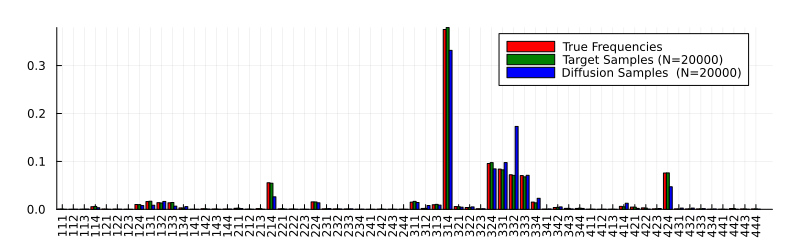

In [21]:
#Plotting
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_flux64.pdf")
pl

In [126]:
using StaticArrays: SVector

struct CategoricalVariables{K, T}
    p::Array{SVector{K, T}}
end

ncategories(::CategoricalVariables{K}) where K = K

Base.size(X::CategoricalVariables) = size(X.p)

In [11]:
function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractVector{Bool})
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    vocab_size = process.vocab_size  # Assume this is a field in your MaskedDiffusionLanguageModel
    num_tokens = length(x) ÷ vocab_size
    
    result = falses(length(x))
    
    for i in 1:num_tokens
        token_slice = (i-1)*vocab_size + 1 : i*vocab_size
        if rand(rng) < p_keep
            # Keep the original token
            result[token_slice] = x[token_slice]
        else
            # Mask the token
            result[token_slice[process.mask_token_id]] = true
        end
    end
    
    return result
end

function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractArray{Bool, 3})
    vocab_size, batch_size, seq_length = size(x)
    
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    result = falses(size(x))
    
    for k in 1:seq_length
        for j in 1:batch_size
            if rand(rng) < p_keep
                # Keep the original token
                result[:, j, k] = x[:, j, k]
            else
                # Mask the token
                result[process.mask_token_id, j, k] = true
            end
        end
    end
    
    return result
end

_sampleforward (generic function with 3 methods)

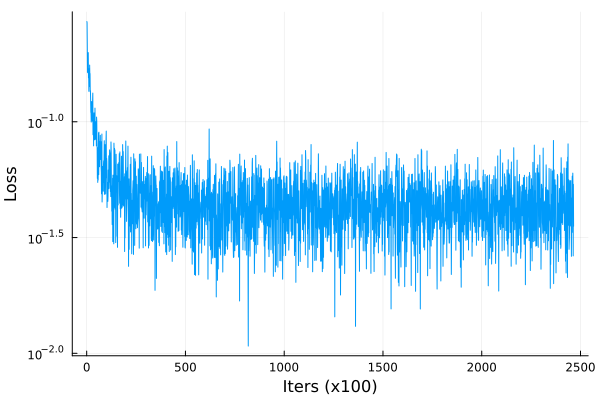

-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.010025993f0
T = 0.28480357f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.08561533f0
T = 0.001149757f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.46732882f0
T = 0.93260336f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.023207793f0
T = 0.06579332f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.2018758f0
T = 0.004037016f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.037626702f0
T = 0.08111307f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.043367904f0
T = 0.0018738174f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.0568551f0
T = 0.005722368f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.06095743f0
T = 0.2009233f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.059649248f0
T = 0.043287612f0
-(Flux.logitcrossentropy(model(diffusedOH, T), datOH)) = -0.023054926f0
T = 0.0021544348f0
-(Flux.logitcrossentr

LoadError: InterruptException:

In [66]:
#Since this IndependentDiscreteDiffusion process is equivalent, the model from above should be "pre-trained"
#let's check if the loss resumes from where it left off
for iter in 1:50000000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    T = rand(timesteps)    

    # @show _sampleforward(rng, P, T, datOH)

    # @show sampleforward(P, T, datOH)

    # @show datOH
    
    # throw(Exception)

    a = P.α(T)

    scal = a[2]/(1-a[2]) 

    diffusedOH = sampleforward(P, T, datOH) #Note, we diffuse the one-hots

    @show -Flux.logitcrossentropy(model(diffusedOH,T), datOH)
    @show T
    # scal = sqrt(1 - exp(-T))
    l,gs = Flux.withgradient(ps) do
        -Flux.logitcrossentropy(model(diffusedOH,T), datOH)*scal
        # -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    end
    Flux.Optimise.update!(opt, ps, gs)
    cumu_loss += l 
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

In [15]:
function _endpoint_conditioned_sample(
    rng::AbstractRNG, 
    process::MaskedDiffusionLanguageModel, 
    s::Real, 
    t::Real, 
    x0::AbstractVector{Bool}, 
    xt::AbstractVector{Bool}
)
    @assert 0 ≤ s < t ≤ 1 "Invalid time steps: require 0 ≤ s < t ≤ 1"
    @assert length(x0) == length(xt) "x0 and xt must have the same length"
    
    vocab_size = process.vocab_size
    sequence_length = length(xt) ÷ vocab_size
    xs = copy(xt)
    
    α_s = process.α(s)[1]
    α_t = process.α(t)[1]

    for i in 1:sequence_length
        token_slice = (i-1)*vocab_size + 1 : i*vocab_size
        if xt[token_slice[process.mask_token_id]]
            probs = zeros(Float32, vocab_size)
            probs[process.mask_token_id] = 1 - α_s
            predicted_token = findfirst(x0[token_slice])
            probs[predicted_token] = α_s - α_t
            probs ./= sum(probs)
            sampled_token = rand(rng, Categorical(probs))
            xs[token_slice] .= false
            xs[token_slice[sampled_token]] = true
        end
    end

    return xs
end

_endpoint_conditioned_sample (generic function with 3 methods)

In [16]:
using Random
using Distributions

# Create a test instance of MaskedDiffusionLanguageModel
test_model = MaskedDiffusionLanguageModel(5, 5, linear)  # mask_token_id is 5, vocab_size is 5

# Test data
test_data = Bool[0 0 0; 0 1 0; 0 0 0; 1 0 1; 0 0 0;;; 
                 0 0 0; 0 1 0; 1 0 0; 0 0 1; 0 0 0;;; 
                 1 0 0; 0 0 1; 0 0 0; 0 0 0; 0 1 0;;; 
                 0 0 1; 0 0 0; 1 1 0; 0 0 0; 0 0 0;;; 
                 0 1 0; 0 0 0; 1 0 0; 0 0 1; 0 0 0;;; 
                 0 0 0; 0 0 0; 1 1 1; 0 0 0; 0 0 0;;; 
                 0 0 0; 0 1 0; 0 0 0; 1 0 1; 0 0 0;;; 
                 0 0 0; 0 1 0; 1 0 1; 0 0 0; 0 0 0]

# Function to flatten the 3D array into the format expected by _endpoint_conditioned_sample
function flatten_data(data)
    vocab_size, batch_size, seq_length = size(data)
    return reshape(permutedims(data, (1, 3, 2)), :, batch_size)
end

# Test function
function test_endpoint_conditioned_sample()
    rng = MersenneTwister(123)  # for reproducibility
    s, t = 0.3, 0.7
    
    # Flatten the test data
    flattened_data = flatten_data(test_data)
    
    # Use the first column as x0 and the second column as xt
    x0 = flattened_data[:, 1]
    xt = flattened_data[:, 2]
    
    # Ensure some tokens in xt are masked
    xt[5:5:end] .= true  # mask every 5th token (corresponding to mask_token_id)
    for i in 1:5:length(xt)
        xt[i:i+3] .= false
    end
    
    println("x0: ", x0)
    println("xt: ", xt)
    
    xs = _endpoint_conditioned_sample(rng, test_model, s, t, x0, xt)
    
    println("xs: ", xs)
    
    # Check that the output is valid
    @assert length(xs) == length(x0) "Output length mismatch"
    @assert all(sum(xs[i:i+4]) == 1 for i in 1:5:length(xs)) "Invalid one-hot encoding in output"
    
    println("Test passed successfully!")
end

# Run the test
test_endpoint_conditioned_sample()

x0: Bool[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
xt: Bool[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]
xs: Bool[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
Test passed successfully!


In [62]:
function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, size(x_t))
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = randcat(rng, probs)
            sampled[:, s, b] = onehotbatch([sampled_token], 1:vocab_size)
        end
    end
    return sampled
end

eq = Categorical(ones(alph)./alph)
N = 10000
seq_length = 3

# Initialize x_T with mask tokens
x_T = falses(alph, seq_length, N)
x_T[5, :, :] .= true  # Assuming 5 is the mask token index

@time samp = samplebackward(zero_sample, P, timesteps, x_T)

# Convert the result to the desired format
diff_samples = [onecold(samp[:, :, i], 1:alph) for i in 1:N]

  4.115151 seconds (27.57 M allocations: 7.762 GiB, 7.37% gc time)


10000-element Vector{Vector{Int64}}:
 [2, 2, 4]
 [3, 3, 4]
 [1, 3, 1]
 [3, 1, 4]
 [3, 2, 4]
 [2, 1, 3]
 [4, 2, 4]
 [3, 3, 2]
 [3, 2, 4]
 [3, 1, 4]
 [3, 1, 4]
 [3, 1, 4]
 [3, 3, 2]
 ⋮
 [3, 1, 4]
 [3, 3, 3]
 [3, 2, 4]
 [3, 1, 3]
 [3, 2, 4]
 [3, 2, 4]
 [3, 1, 4]
 [2, 1, 4]
 [1, 2, 4]
 [3, 1, 4]
 [4, 2, 1]
 [3, 1, 4]

In [21]:
function zero_sample(x_t, t)
    #randcat here maintains onehot
    sm = softmax(model(x_t,t))
    return onehotbatch(randcat(rng, sm),1:size(sm,1))
end

eq = Categorical(ones(alph)./alph);
N = 10
#We init with onehots
# x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);
x_T = onehotbatch(hcat([[5 for i in 1:3] for i in 1:N]...), 1:alph);

# @time samp = onecold(samplebackward(zero_sample, P, timesteps, x_T),1:alph);
# diff_samples = [samp[:,i] for i in 1:size(samp,2)];

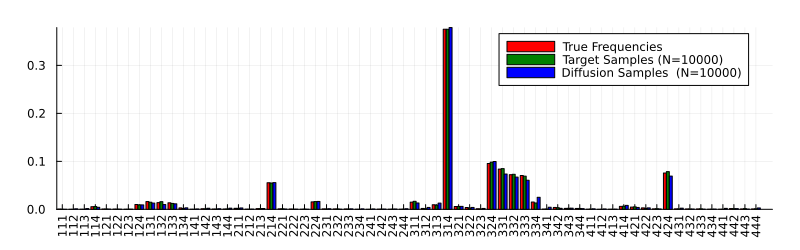

In [63]:
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_fluxIJ.pdf")
pl

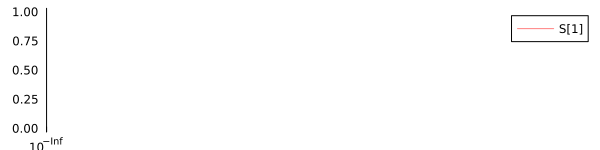

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/8mrSm/src/ticks.jl:194


In [20]:
#A trajectory with an NN-trained model
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:1]...), 1:alph);
track = Diffusions.Tracker()
samp = onecold(samplebackward(zero_sample, P, timesteps, x_T, tracker = track),1:alph);

#An example of a single discrete trajectory
plot(track.time,hcat([v[:] for v in onecold.(track.data,(1:alph,))]...)', xscale = :log10, alpha = 0.5, size = (600,150), 
    legend=:outertopright, color = ["red" "green" "blue"], label = ["S[1]" "S[2]" "S[2]"])

In [29]:
#Using the expected freqs, without sampling, does NOT work for the discrete case!
function expect(x_t, t)
    return softmax(model(x_t,t)) #Just the exepected freqs
end

N = 1000
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);

samp = onecold(samplebackward(expect, P, timesteps, x_T),1:alph);
diff_samples = [samp[:,i] for i in 1:size(samp,2)];

target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Bad Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_flux_nosample.pdf")
pl

LoadError: UndefVarError: `CuArray` not defined

In [14]:
#Closed-form (ie. no trained NN) to investigate behavior/convergence etc.

#"product of marginals" for each variable in the sequence
#This is what you get from the backward pass, because each variable is diffused independently
#For the closed form calculation, this is P(xt|x0), where "seq" is x0, considered as a function of x0.
independent_seq_prob(seq,state) = state[seq[1],1]*state[seq[2],2]*state[seq[3],3]

#The above gets multiplied by P(x0) (ie. all_probs, the target distribution) to get P(x0|xt) ∝ P(x0)P(xt|x0)
#The marginals for each variable in x0 are then sampled from, independently.
function direct_zero_sample(x_t, T; P = P, all_seqs = all_seqs, all_probs = all_probs)
    backw = Diffusions.backward(P,x_t,0.0,T)
    for i in 1:size(x_t,3)
        bck = backw[:,:,i]
        p = all_probs .* independent_seq_prob.(all_seqs,(bck,))
        p = p ./ sum(p)

        #Calculating the "per site" probabilities implied by the joint p
        bck .= 0.0
        for (i,s) in enumerate(all_seqs)
            bck[s[1],1] += p[i]
            bck[s[2],2] += p[i]
            bck[s[3],3] += p[i]
        end
        bck .= bck ./ sum(bck, dims = 1) 
        backw[:,:,i] .= onehotbatch(randcat(bck),1:size(bck,1)) #flag
    end
    return backw
end

direct_zero_sample (generic function with 1 method)

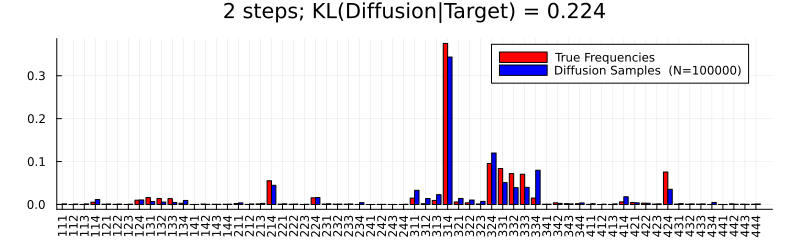

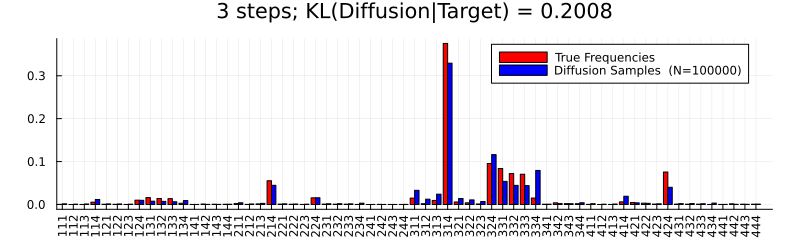

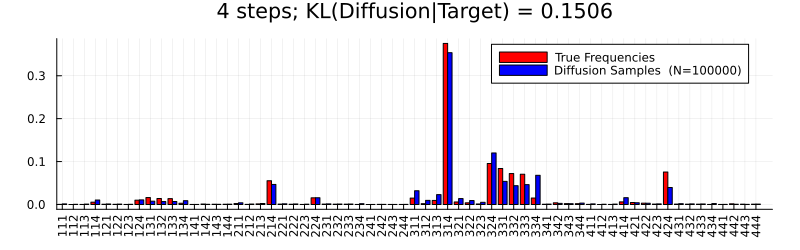

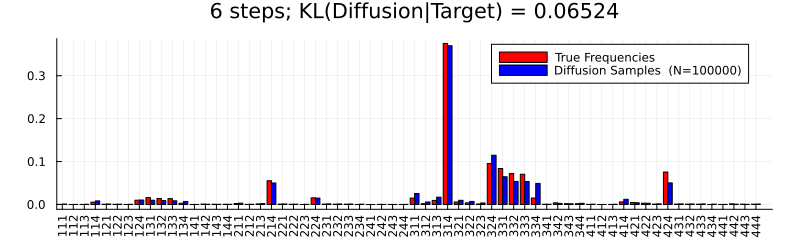

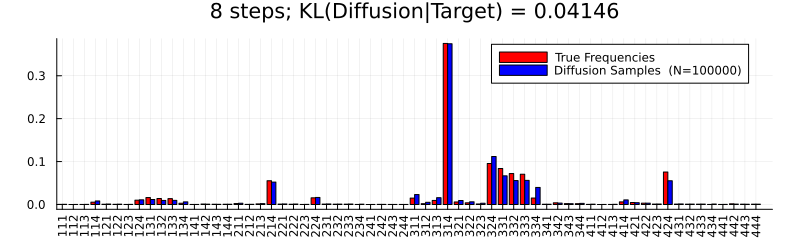

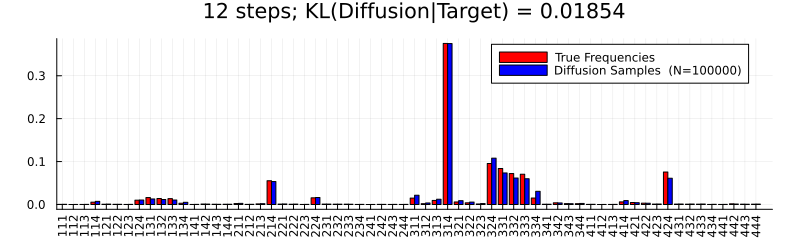

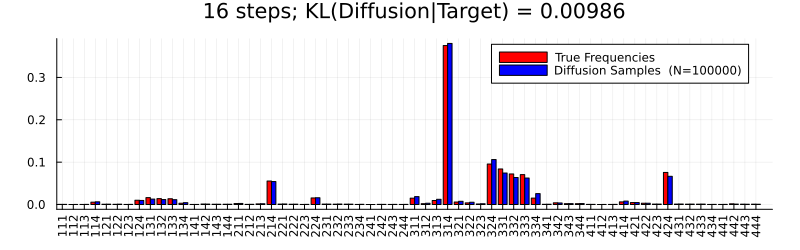

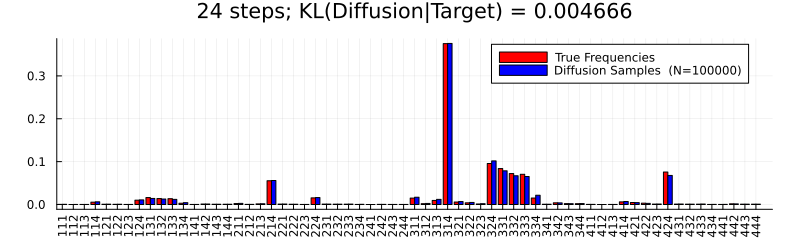

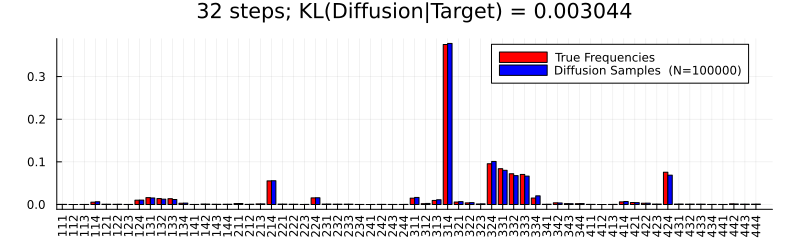

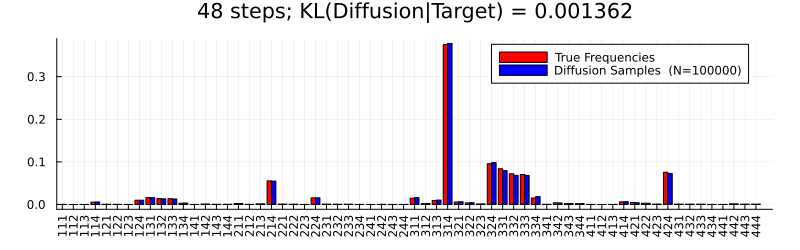

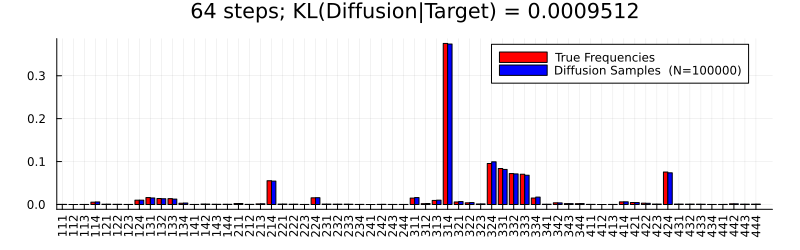

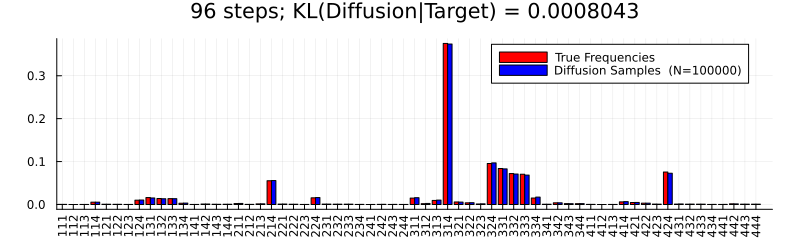

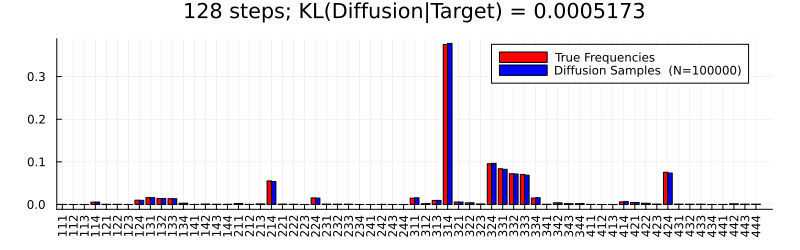

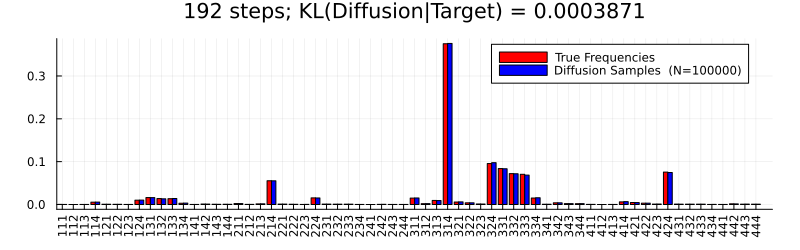

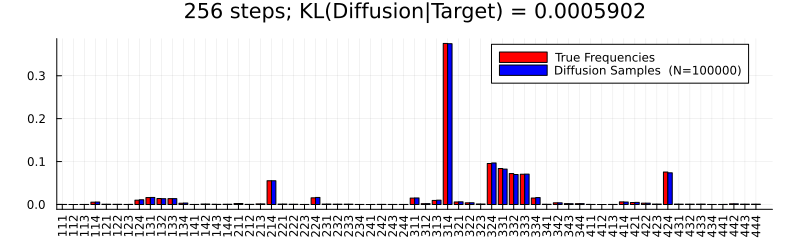

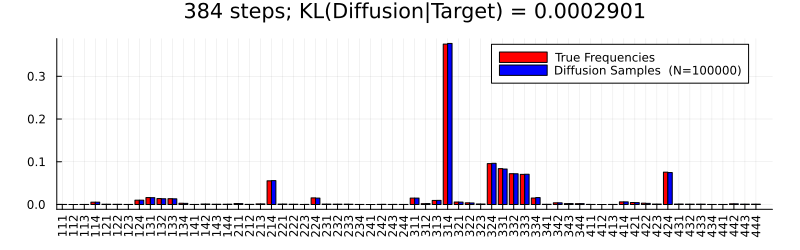

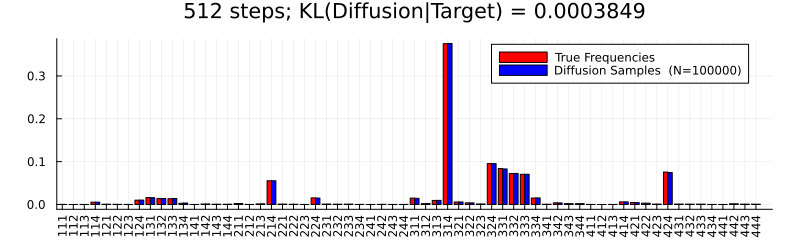

In [15]:
#Investigating the convergence on the true joint distribution using the direct expectation calculation
KLterm(p,q) = p > 0 ? p*log(p/q) : 0.0
KLdiv(Pdict,Qdict) = sum([KLterm(get(Pdict,k,0.0),get(Qdict,k,0.0)) for k in union(keys(Pdict),keys(Qdict))])

KLDs = Float64[]

steplist = [2,3,4,6,8,12,16,24,32,48,64,96,128,192,256,384,512]
for steps in steplist
    timesteps = timeschedule(exp, Float32(0.001),Float32(20.0),steps+1)

    eq = Categorical(ones(alph)./alph);
    N = 100000
    x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:N]...), 1:alph);

    samp = onecold(samplebackward(direct_zero_sample, P, timesteps, x_T),1:alph);
    diff_samples = [samp[:,i] for i in 1:size(samp,2)];
    prop_d = proportionmap(diff_samples)
    

    diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
    
    kld = round(KLdiv(prop_d,Dict(zip(all_seqs,all_probs))), sigdigits = 4)
    push!(KLDs,kld)
    
    pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs diff_freqs],
        xrotation = 90, size = (800,250), label = ["True Frequencies" "Diffusion Samples  (N=$(N))"],
        color = ["red" "blue"], margins = 0.5Plots.cm, xlim = (0,65), title = "$(steps) steps; KL(Diffusion|Target) = $(kld)")
    display(pl)
    if steps in [2,16,64,256]
        savefig(pl,"discrete_diff_direct_$(steps)_steps.pdf")
    end
end

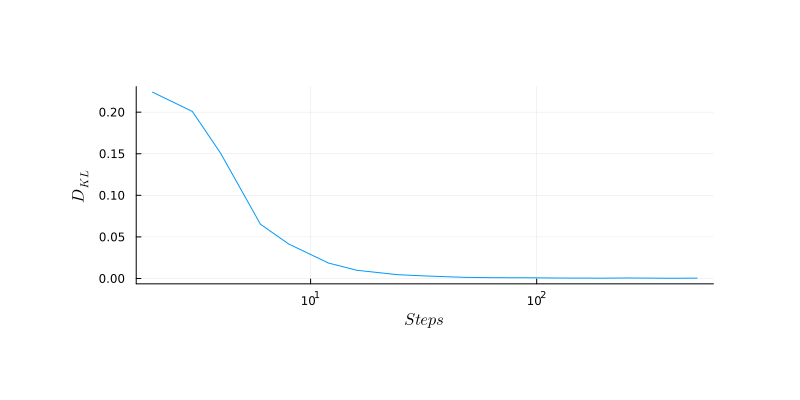

In [16]:
#KL divergence of samples vs true distribution as sampling steps increases
pl = plot(steplist, KLDs, xscale = :log10, size = (800,400),
    ylabel = L"D_{KL}", margins = 2Plots.cm, label = :none, xlabel = L"Steps")
savefig(pl,"discrete_KL_vs_steps_logschedule.pdf")
pl

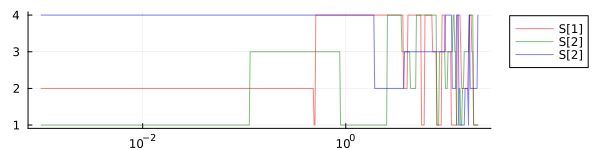

In [17]:
#A trajectory with an directly calculated zero sample
x_T = onehotbatch(hcat([[rand(eq) for i in 1:3] for i in 1:1]...), 1:alph);
track = Diffusions.Tracker()
samp = onecold(samplebackward(direct_zero_sample, P, timesteps, x_T, tracker = track),1:alph);

#An example of a single discrete trajectory
plot(track.time,hcat([v[:] for v in onecold.(track.data,(1:alph,))]...)', xscale = :log10, alpha = 0.5, size = (600,150), 
    legend=:outertopright, color = ["red" "green" "blue"], label = ["S[1]" "S[2]" "S[2]"])